<a href="https://colab.research.google.com/github/vishakhaCOder/barca-defensive-analysis/blob/main/barca-defensive-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Searching StatsBomb free dataset specifically for El Clásico (Barcelona vs. Real Madrid)...

Match Selected: Real Madrid 2 - 1 Barcelona (2021-04-10)
Match ID: 3773497

EL CLÁSICO BARCELONA DEFENSIVE ANALYSIS: REAL MADRID 2 - 1 BARCELONA (2021-04-10)

TABLE 1: DEFENSIVE ACTIONS BY PITCH ZONE
--------------------------------------------------
pitch_zone    Attacking Third (High Press)  Defensive Third  Middle Third  \
type                                                                        
Block                                    2               11             4   
Duel                                     7                7             6   
Interception                             2                1             1   
Pressure                                55               46            43   

pitch_zone    Total Actions  
type                         
Block                    17  
Duel                     20  
Interception              4  
Pressure                144  

TABLE 2: BAR

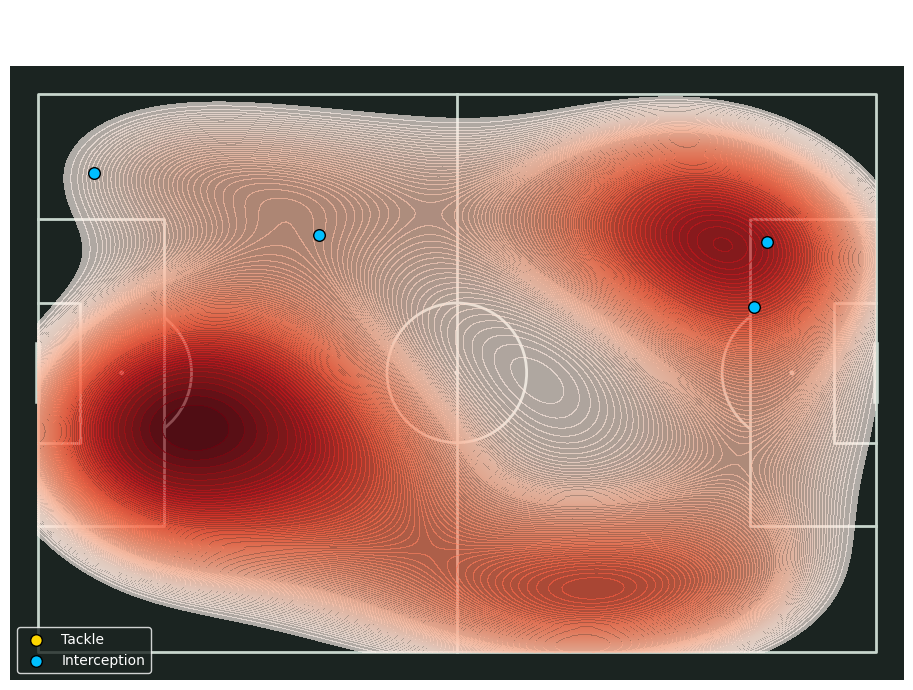

In [10]:

!pip install -q statsbombpy mplsoccer matplotlib pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb
from mplsoccer import Pitch

print("Searching StatsBomb free dataset specifically for El Clásico (Barcelona vs. Real Madrid)...")

#Query La Liga seasons for a Barcelona vs. Real Madrid match
comps = sb.competitions()
la_liga_seasons = comps[comps['competition_id'] == 11]['season_id'].unique()

selected_match_id = None
match_info = ""

for season_id in la_liga_seasons:
    matches = sb.matches(competition_id=11, season_id=season_id)

    # Filter for El Clásico
    clasico = matches[
        ((matches['home_team'] == 'Barcelona') & (matches['away_team'] == 'Real Madrid')) |
        ((matches['home_team'] == 'Real Madrid') & (matches['away_team'] == 'Barcelona'))
    ]

    if not clasico.empty:
        match_row = clasico.iloc[0]
        selected_match_id = match_row['match_id']
        home_team = match_row['home_team']
        away_team = match_row['away_team']
        score = f"{match_row['home_score']} - {match_row['away_score']}"
        date = match_row['match_date']
        match_info = f"{home_team} {score} {away_team} ({date})"
        break

if not selected_match_id:
    raise ValueError("No El Clásico match found in the current free dataset partition.")

print(f"\nMatch Selected: {match_info}")
print(f"Match ID: {selected_match_id}")
print("Downloading match events...")

#Load Events Data
events = sb.events(match_id=selected_match_id)

#Filter strictly for FC Barcelona defensive actions
defensive_types = ['Pressure', 'Tackle', 'Interception', 'Block', 'Duel', '50/50']
barca_def = events[(events['team'] == 'Barcelona') & (events['type'].isin(defensive_types))].copy()

#Extract and parse spatial coordinates (x, y)
barca_def['x'] = barca_def['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
barca_def['y'] = barca_def['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)
barca_def = barca_def.dropna(subset=['x', 'y'])

#Categorize defensive zones based on pitch location (x-axis in StatsBomb goes 0 to 120)
def assign_zone(x):
    if x < 40: return 'Defensive Third'
    elif x < 80: return 'Middle Third'
    else: return 'Attacking Third (High Press)'

barca_def['pitch_zone'] = barca_def['x'].apply(assign_zone)

# --- TABLE 1: Action Type Breakdown Across Pitch Zones ---
table_1 = barca_def.groupby(['type', 'pitch_zone']).size().unstack(fill_value=0)
table_1['Total Actions'] = table_1.sum(axis=1)

# --- TABLE 2: Barcelona Pressing & Defensive Height Profile ---
total_actions = len(barca_def)
high_press_cnt = len(barca_def[barca_def['pitch_zone'] == 'Attacking Third (High Press)'])
mid_block_cnt = len(barca_def[barca_def['pitch_zone'] == 'Middle Third'])
low_block_cnt = len(barca_def[barca_def['pitch_zone'] == 'Defensive Third'])

avg_height_meters = (barca_def['x'].mean() * (105 / 120)) if total_actions > 0 else 0
high_press_pct = ((high_press_cnt / total_actions) * 100) if total_actions > 0 else 0

table_2 = pd.DataFrame({
    'Defensive Metric': [
        'Total Defensive Actions',
        'High Press Actions (Attacking 3rd)',
        'Mid-Block Actions (Middle 3rd)',
        'Low-Block Actions (Defensive 3rd)',
        'High Pressing Ratio (%)',
        'Average Defensive Action Height'
    ],
    'Value': [
        total_actions, high_press_cnt, mid_block_cnt, low_block_cnt,
        f"{high_press_pct:.1f}%",
        f"{avg_height_meters:.2f} meters from own goal"
    ]
})

# --- TABLE 3: Individual Player Defensive Leaderboard ---
table_3 = barca_def.groupby('player').agg(
    Pressures=('type', lambda x: (x == 'Pressure').sum()),
    Tackles=('type', lambda x: (x == 'Tackle').sum()),
    Interceptions=('type', lambda x: (x == 'Interception').sum()),
    Blocks=('type', lambda x: (x == 'Block').sum()),
    Avg_Height_X=('x', 'mean')
).sort_values(by='Pressures', ascending=False).head(8)

table_3['Avg_Action_Meters'] = (table_3['Avg_Height_X'] * (105 / 120)).round(2)
table_3 = table_3.drop(columns=['Avg_Height_X'])

# Print Quantitative Summaries
print("\n" + "="*65)
print(f"EL CLÁSICO BARCELONA DEFENSIVE ANALYSIS: {match_info.upper()}")
print("="*65)

print("\nTABLE 1: DEFENSIVE ACTIONS BY PITCH ZONE")
print("-" * 50)
print(table_1)

print("\nTABLE 2: BARCELONA DEFENSIVE PROFILE METRICS")
print("-" * 50)
print(table_2.to_string(index=False))

print("\nTABLE 3: PLAYER DEFENSIVE LEADERBOARD")
print("-" * 50)
print(table_3)

#VISUALIZATION: Barcelona Defensive Density & Map
pitch = Pitch(pitch_type='statsbomb', line_color='#c7d5cc', pitch_color='#1b2421')
fig, ax = pitch.draw(figsize=(11, 7))

#Kernel Density Estimation (Heatmap) for Pressures
pitch.kdeplot(barca_def['x'], barca_def['y'], ax=ax, fill=True, levels=100, thresh=0.05, cmap='Reds', alpha=0.65)

#Plot Tackles and Interceptions on top
tackles = barca_def[barca_def['type'] == 'Tackle']
interceptions = barca_def[barca_def['type'] == 'Interception']

pitch.scatter(tackles['x'], tackles['y'], ax=ax, color='#ffd700', edgecolors='black', s=70, label='Tackle', zorder=3)
pitch.scatter(interceptions['x'], interceptions['y'], ax=ax, color='#00bfff', edgecolors='black', s=70, label='Interception', zorder=3)

plt.title(f"FC Barcelona Defensive Structure vs Real Madrid\n{match_info}", color='white', fontsize=13, pad=15)
plt.legend(loc='lower left', facecolor='#1b2421', edgecolor='white', labelcolor='white')
plt.show()